<a href="https://colab.research.google.com/github/uuu4/yz50/blob/main/week1_YZ50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# task 1
1. Python ile tek nöron forward pass yaz, kütüphane kullanmadan. (1. video)

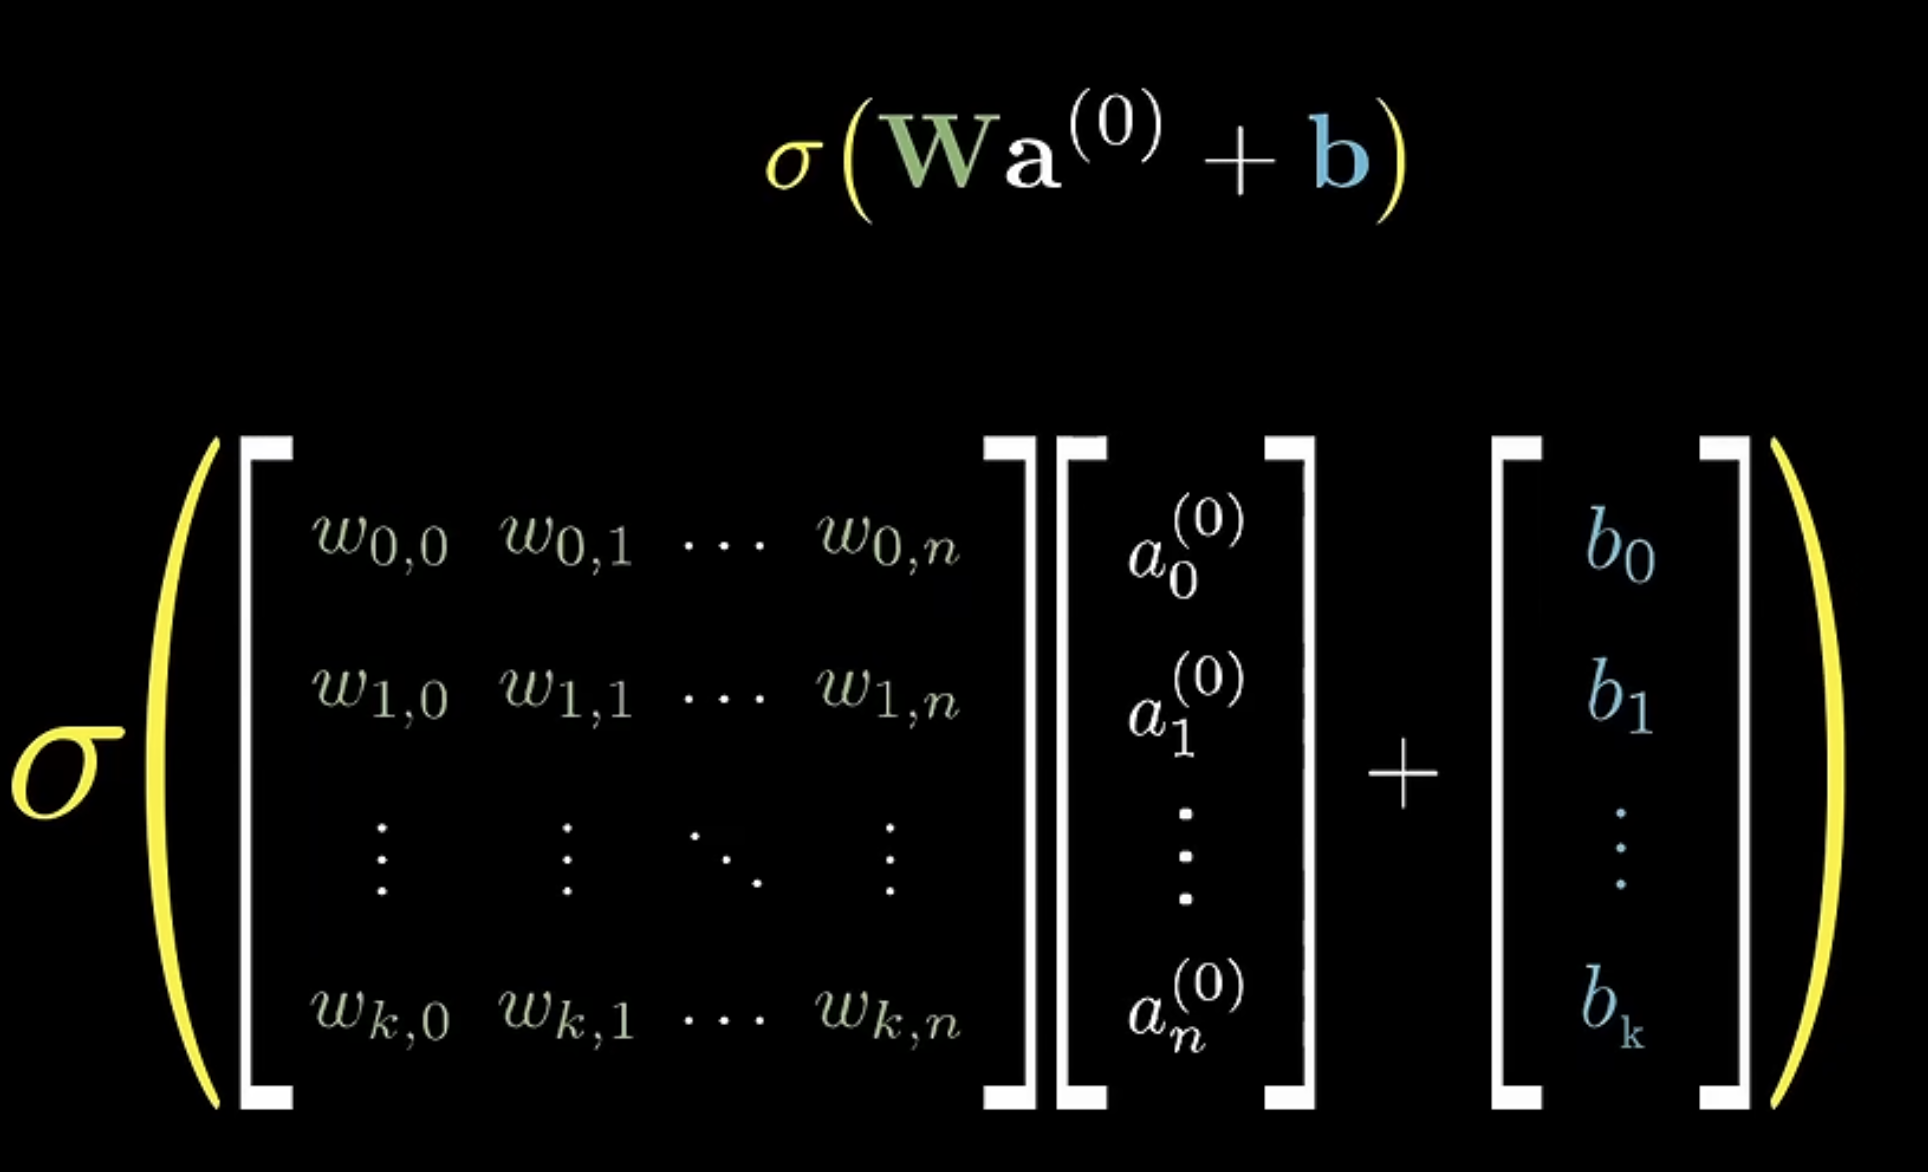



Lineer cebir notasyonu ile gösterebiliriz.

tek bir nöronumuz olacağından dolayı matrislerden ziyade bir python listesi ile ilerleyebiliriz.
Girdileri alan, ağırlıklar ile çarpan en son bias ekleyip bir activation functiona sıkıştıran bir yapı.

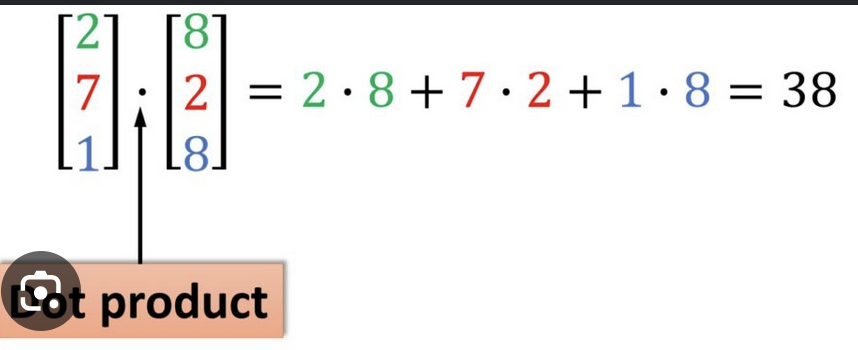 tek noron forward pass icin yapmamiz gereken islem bu fakat numpy kullanmamiz yasak oldugundan dongu icerisinde dot producti implemente etmemiz gerekiyor

In [ ]:
x = [0.2,0.5,0.6,0.3]
w1 = [1,1,1,1] #input sayisi kadar agirlik ile init etmemiz gerekiyor,
# ileride parametrelerin nasil degistigini gostermek icin hepsini 1 ile baslatacagim

def dot_product(x,w): #belki dimensionlarin ayni olduguna dair bir try catch yapilabilabilir
  total = 0.0
  for i in range(len(x)):
    total += x[i]*w[i]
  return total

def forward_pass(x,w,b):
  return dot_product(x,w)+b


# task 2
2. Birden fazla nörondan oluşan küçük bir katman kur, forward pass'i buna genişlet. (1. video)

bunun icin bir layer mantigi kurgulamamiz gerekiyor. layerin icerisindeki noron sayisi kadar forward pass yapilacak


In [ ]:
w2 = [0.5,0.5,0.5,0.5]
w3 = [0.2,0.2,0.2,0.2]
weights = [w1,w2,w3]

b1 = 5
b2 = 10
b3 = 15

biases = [b1,b2,b3]
def layer_forward(x,weights,biases): # yine weights ile biases dimension check yapilabilir
  output = []
  for i in range(len(weights)):
    output.append(forward_pass(x,weights[i],biases[i]))
  return output


# task 3
3. Basit bir loss fonksiyonu yaz. (2. video)

bunun icin bir suru secenegimiz var ama en basiti olan MSE (mean squared error) ile devam edebiliriz ek olarak rmse ekleyecegim.

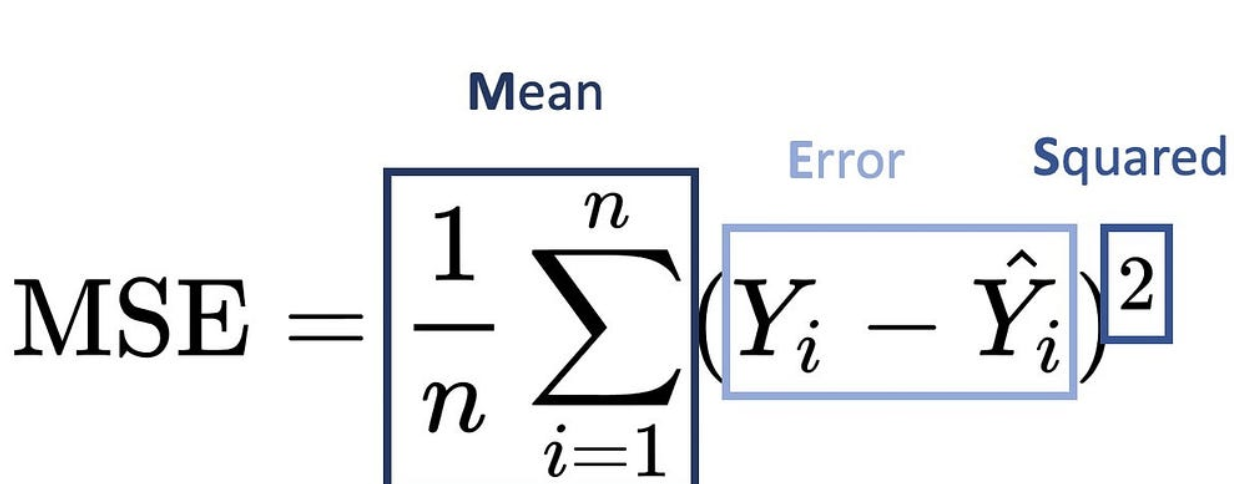

In [ ]:
def mse(y_pred,y_true,n): # noron sayisi kadar hata terimi cikacak
  total = 0.0
  for i in range(n):
    total+=(y_true[i]-y_pred[i])**2
  return total/n

# task 4
4. Parametreleri manuel değiştirerek loss'un nasıl değiştiğini gözlemle, loss eğrisini çiz. (2. video)



In [ ]:
y_true = [3,4,5] # kafadan attim
losses = []

w_test = -2.0
while w_test <= 2.0:
  # anlamli degisim gormek icin sadece 1 agirligi degistiriyorum
  w1[0] = w_test
  y_pred = layer_forward(x,weights,biases)
  losses.append(mse(y_pred,y_true,len(weights)))
  w_test+=0.1

print(losses)




[53.914133333333346, 53.954266666666676, 53.99466666666667, 54.03533333333334, 54.076266666666676, 54.11746666666667, 54.158933333333344, 54.20066666666668, 54.24266666666667, 54.284933333333335, 54.32746666666667, 54.37026666666668, 54.413333333333334, 54.45666666666667, 54.500266666666676, 54.54413333333334, 54.58826666666668, 54.63266666666667, 54.67733333333334, 54.72226666666668, 54.76746666666668, 54.81293333333334, 54.85866666666667, 54.90466666666668, 54.950933333333346, 54.997466666666675, 55.04426666666668, 55.09133333333333, 55.13866666666667, 55.186266666666675, 55.23413333333334, 55.28226666666668, 55.33066666666667, 55.37933333333334, 55.42826666666667, 55.47746666666668, 55.52693333333334, 55.576666666666675, 55.62666666666667, 55.676933333333345]


# task 5
 5.

Sayısal türev (numerical derivative) ile basit bir gradient descent

döngüsü kur: parametreyi küçük adımlarla güncelleyerek loss'u düşür

task 4te farkettik ki agirligi kafamiza gore degistirmek lossu dusurmuyor aksine arttirabiliyor bunun icin bir cost landscape kurup global minimumu yakalamaya calisiyoruz bu da GD/SGD/adam gibi optimizerlar ile oluyor

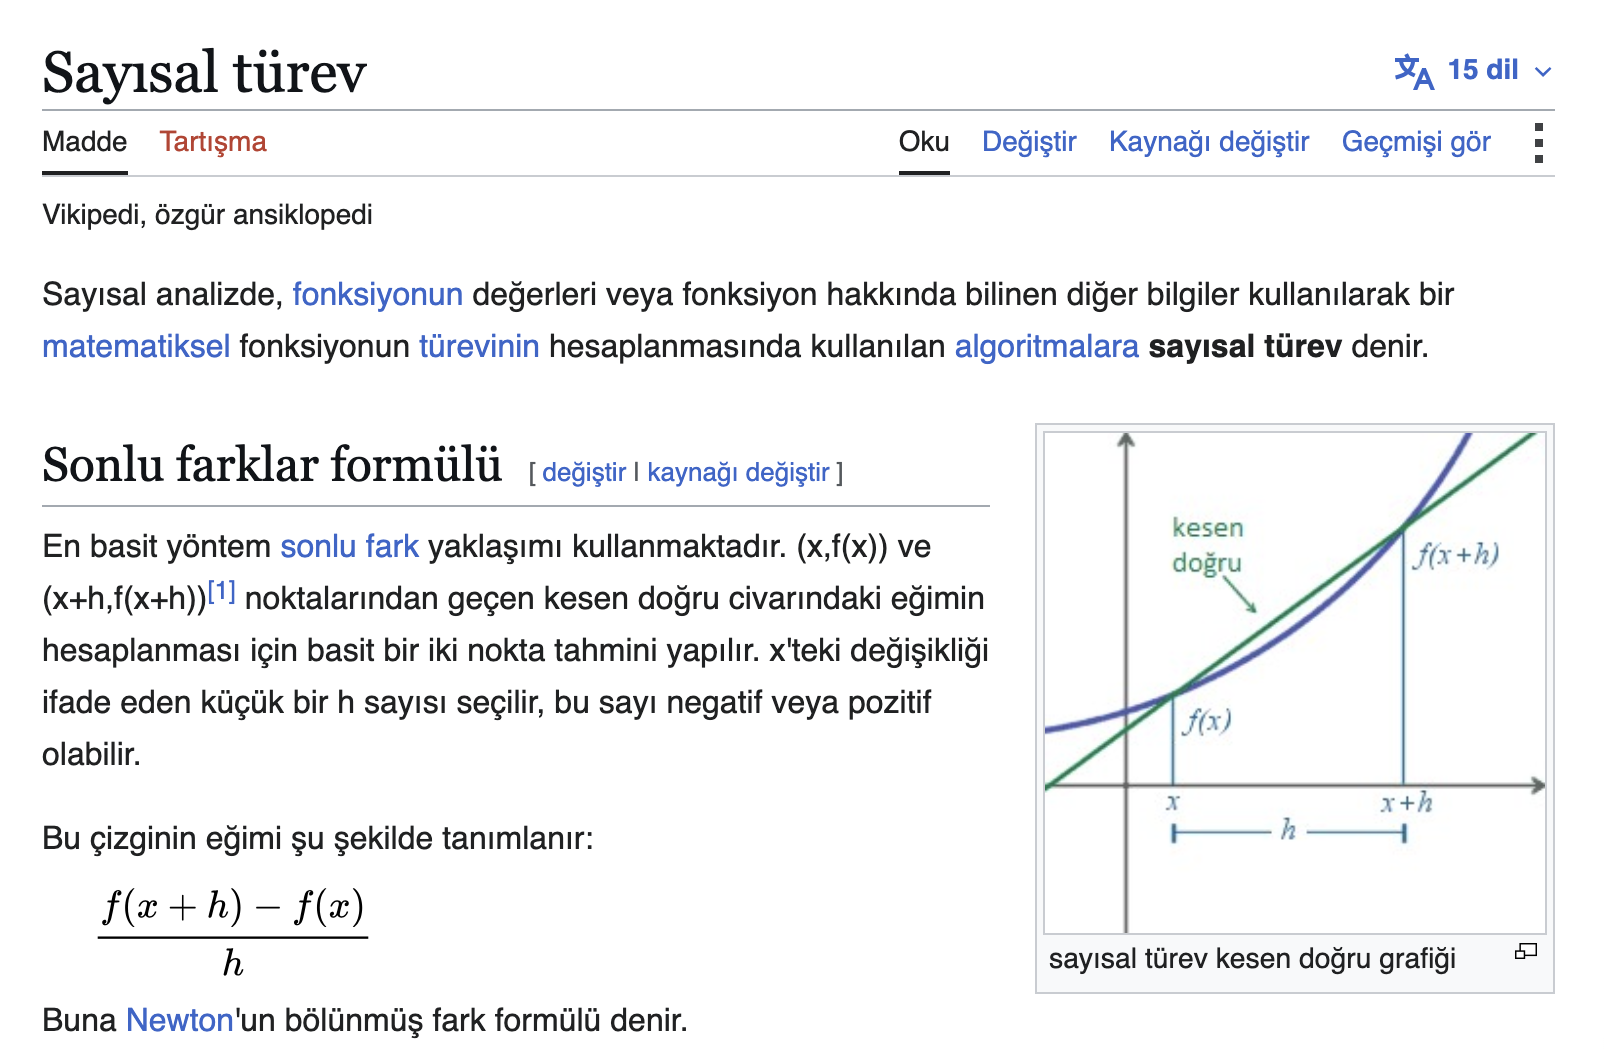

obur formulu
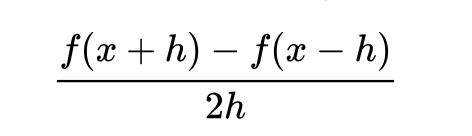

In [ ]:
def gradient(x, w, b, y_true, idx, eps=1e-4):
  w_plus = w.copy()
  w_minus = w.copy()
  w_plus[idx] += eps
  w_minus[idx] -= eps

  loss_plus = (forward_pass(x, w_plus, b) - y_true) ** 2
  loss_minus = (forward_pass(x, w_minus, b) - y_true) ** 2

  return (loss_plus - loss_minus) / (2 * eps)

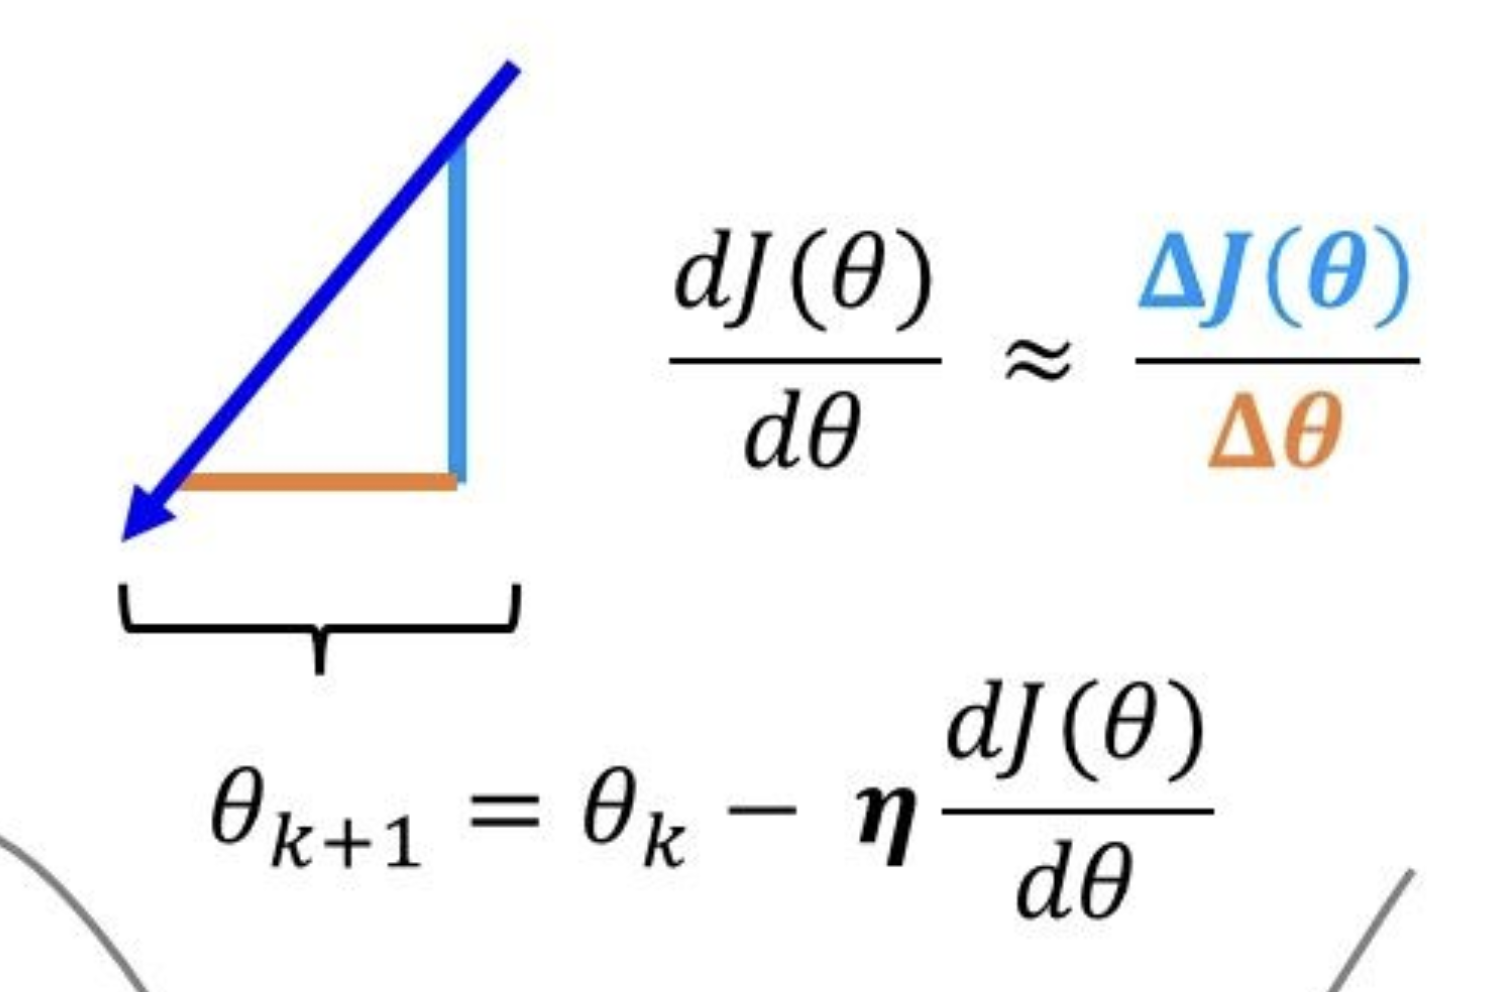

In [ ]:
def descent(x, w_init, b, y_true, idx=0, lr=0.01, steps=500, eps=1e-4):
  w = w_init.copy()
  params = [w.copy()]
  losses = []
  for step in range(steps):
    grad = gradient(x, w, b, y_true, idx)
    w[idx] -= lr * grad
    params.append(w.copy())
    loss = (forward_pass(x, w, b) - y_true) ** 2
    losses.append(loss)
  return w, params , losses

w_son , hist,loss = descent(x,w1,b1,y_true[0])
print(loss)

[14.26554770457595, 14.242731958199007, 14.219952702414103, 14.197209878859903, 14.174503429267995, 14.151833295463161, 14.129199419363498, 14.10660174297988, 14.084040208416083, 14.061514757868249, 14.039025333625013, 14.016571878067227, 13.994154333668098, 13.971772642992905, 13.94942674869847, 13.927116593533547, 13.904842120338424, 13.882603272044781, 13.860399991675552, 13.838232222344798, 13.816099907257557, 13.794002989709718, 13.771941413088008, 13.74991512086947, 13.727924056621584, 13.705968164002263, 13.684047386759328, 13.66216166873063, 13.640310953843917, 13.618495186116574, 13.59671430965561, 13.574968268657134, 13.553257007406751, 13.531580470279286, 13.50993860173827, 13.488331346336057, 13.466758648713833, 13.445220453601207, 13.423716705816357, 13.402247350265622, 13.380812331943375, 13.359411595932022, 13.33804508740174, 13.316712751610607, 13.295414533904072, 13.274150379714968, 13.252920234563492, 13.231724044056966, 13.210561753889689, 13.189433309842943, 13.1683